# Eksplorasi Pertemuan 2 — Efek Learning Rate
Plot kurva loss untuk beberapa learning rate dan temukan yang divergen.

In [4]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
from regresi import buat_data, latih
X, y = buat_data()

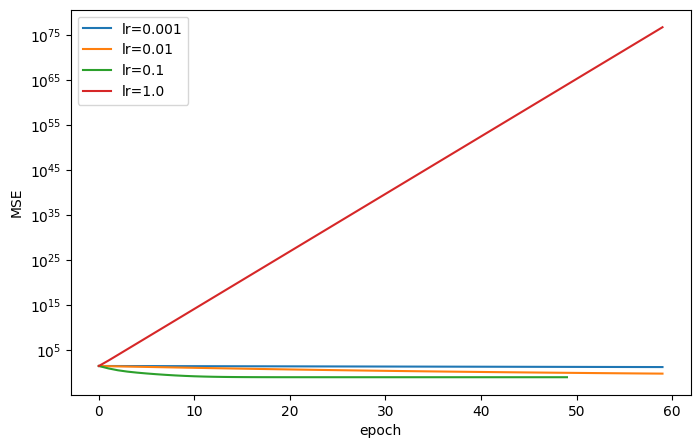

In [5]:
plt.figure(figsize=(8, 5))
for lr in [0.001, 0.01, 0.1, 1.0]:
    try:
        _, _, riwayat = latih(X, y, lr=lr, epochs=100)
        plt.plot(riwayat[:60], label=f"lr={lr}")
    except Exception as e:
        print(f"lr={lr} error: {e}")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend(); plt.show()

## Tabel Lembar Kerja Learning Rate

Cell berikut mencetak angka yang dipakai pada `SUBMISSION.md`: loss akhir, status konvergen, serta nilai `w` dan `b` untuk beberapa learning rate.

In [6]:
import numpy as np
import pandas as pd

baris = []
for lr in [0.001, 0.01, 0.1, 1.0]:
    with np.errstate(over="ignore", invalid="ignore"):
        w, b, riwayat = latih(X, y, lr=lr, epochs=500)
    loss_akhir = riwayat[-1]
    konvergen = np.isfinite(loss_akhir)
    baris.append({
        "Learning rate": lr,
        "Loss akhir": loss_akhir,
        "Konvergen?": "Ya" if konvergen else "Tidak",
        "w akhir": w,
        "b akhir": b,
        "Epoch berjalan": len(riwayat),
    })

hasil_lr = pd.DataFrame(baris)
display(hasil_lr.style.format({
    "Learning rate": "{:.3g}",
    "Loss akhir": lambda v: "nan" if not np.isfinite(v) else f"{v:.6f}",
    "w akhir": lambda v: "nan" if not np.isfinite(v) else f"{v:.4f}",
    "b akhir": lambda v: "nan" if not np.isfinite(v) else f"{v:.4f}",
}))


,Learning rate,Loss akhir,Konvergen?,w akhir,b akhir,Epoch berjalan
0,0.001,0.813787,Ya,2.7686,1.2183,500
1,0.01,0.086298,Ya,3.0038,1.9960,475
2,0.1,0.086298,Ya,3.0038,1.9961,50
3,1,nan,Tidak,nan,nan,500


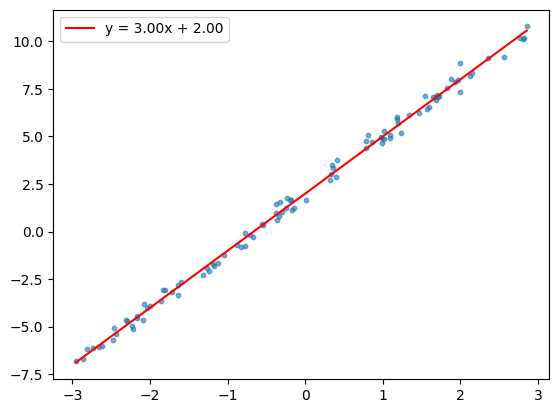

In [7]:
# Visualisasi garis regresi hasil belajar
w, b, _ = latih(X, y, lr=0.05, epochs=300)
plt.scatter(X, y, s=10, alpha=0.6)
import numpy as np
xs = np.linspace(X.min(), X.max(), 10)
plt.plot(xs, w * xs + b, "r", label=f"y = {w:.2f}x + {b:.2f}")
plt.legend(); plt.show()